# Lazy FCA (Formal Concept Analysis) Classifcation

Raimova Alina, Abramov Aleksandr

Task: https://gitlab.com/Al_Toretto/lazy_fca_learning

## EDA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from typing import List, Any
import warnings
warnings.filterwarnings('ignore')

In [3]:
# options
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
print('Unique values for column: ')
for col in df.drop(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges'], axis=1).columns:
    print(f"  - {col}: {df[col].unique()}")

Unique values for column: 
  - gender: ['Female' 'Male']
  - Partner: ['Yes' 'No']
  - Dependents: ['No' 'Yes']
  - PhoneService: ['No' 'Yes']
  - MultipleLines: ['No phone service' 'No' 'Yes']
  - InternetService: ['DSL' 'Fiber optic' 'No']
  - OnlineSecurity: ['No' 'Yes' 'No internet service']
  - OnlineBackup: ['Yes' 'No' 'No internet service']
  - DeviceProtection: ['No' 'Yes' 'No internet service']
  - TechSupport: ['No' 'Yes' 'No internet service']
  - StreamingTV: ['No' 'Yes' 'No internet service']
  - StreamingMovies: ['No' 'Yes' 'No internet service']
  - Contract: ['Month-to-month' 'One year' 'Two year']
  - PaperlessBilling: ['Yes' 'No']
  - PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  - TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
  - Churn: ['No' 'Yes']


Here, we can see that feature `TotalCharges` must be numeric but it is string, because some missing values which was replaced with empty string. So, check it

In [9]:
print(f"Number of empy (space) string in cell: {df[df['TotalCharges'] == ' '].shape[0]}")

Number of empy (space) string in cell: 11


Let's delete this rows

In [10]:
df = df[df['TotalCharges'] != ' ']
df.shape

(7032, 21)

In [11]:
df.loc[:, 'TotalCharges'] = df['TotalCharges'].astype(float)

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208
std,0.368844,24.545260,30.085974
min,0.000000,1.000000,18.250000
25%,0.000000,9.000000,35.587500
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.862500
max,1.000000,72.000000,118.750000


In [13]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5890
1,1142


Also, as we can see, the feature `SeniorCitizen` is the binary feature

In [14]:
print('Class balance')
print(df['Churn'].value_counts())
print('\nClass distribution:')
print(df['Churn'].value_counts(normalize=True))

Class balance
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Class distribution:
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [15]:
df.loc[:, 'Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### Visualizations

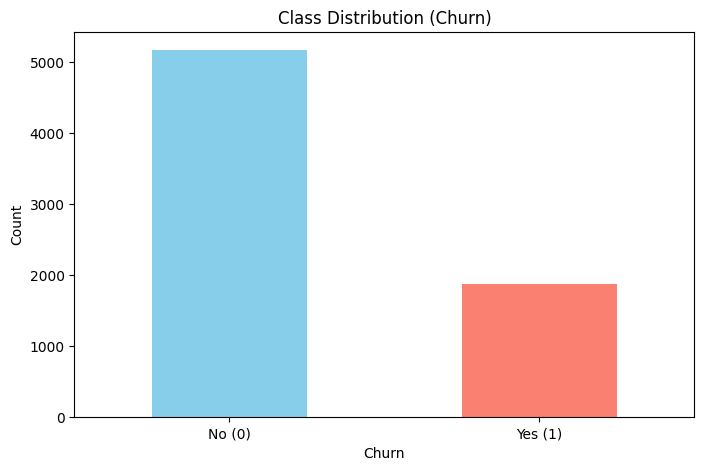

In [16]:
# Class distribution
plt.figure(figsize=(8, 5))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution (Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], rotation=0)
plt.show()

# Correlation analysis for numeric features
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
correlations = df[numeric_cols + ['Churn']].corr()['Churn'].drop('Churn')
correlations.plot(kind='barh', figsize=(8, 5))
plt.title('Correlation between Churn and Numeric Features')
plt.xlabel('Correlation')
plt.show()

# Distribution of numeric features by Churn
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')

plt.tight_layout()
plt.show()

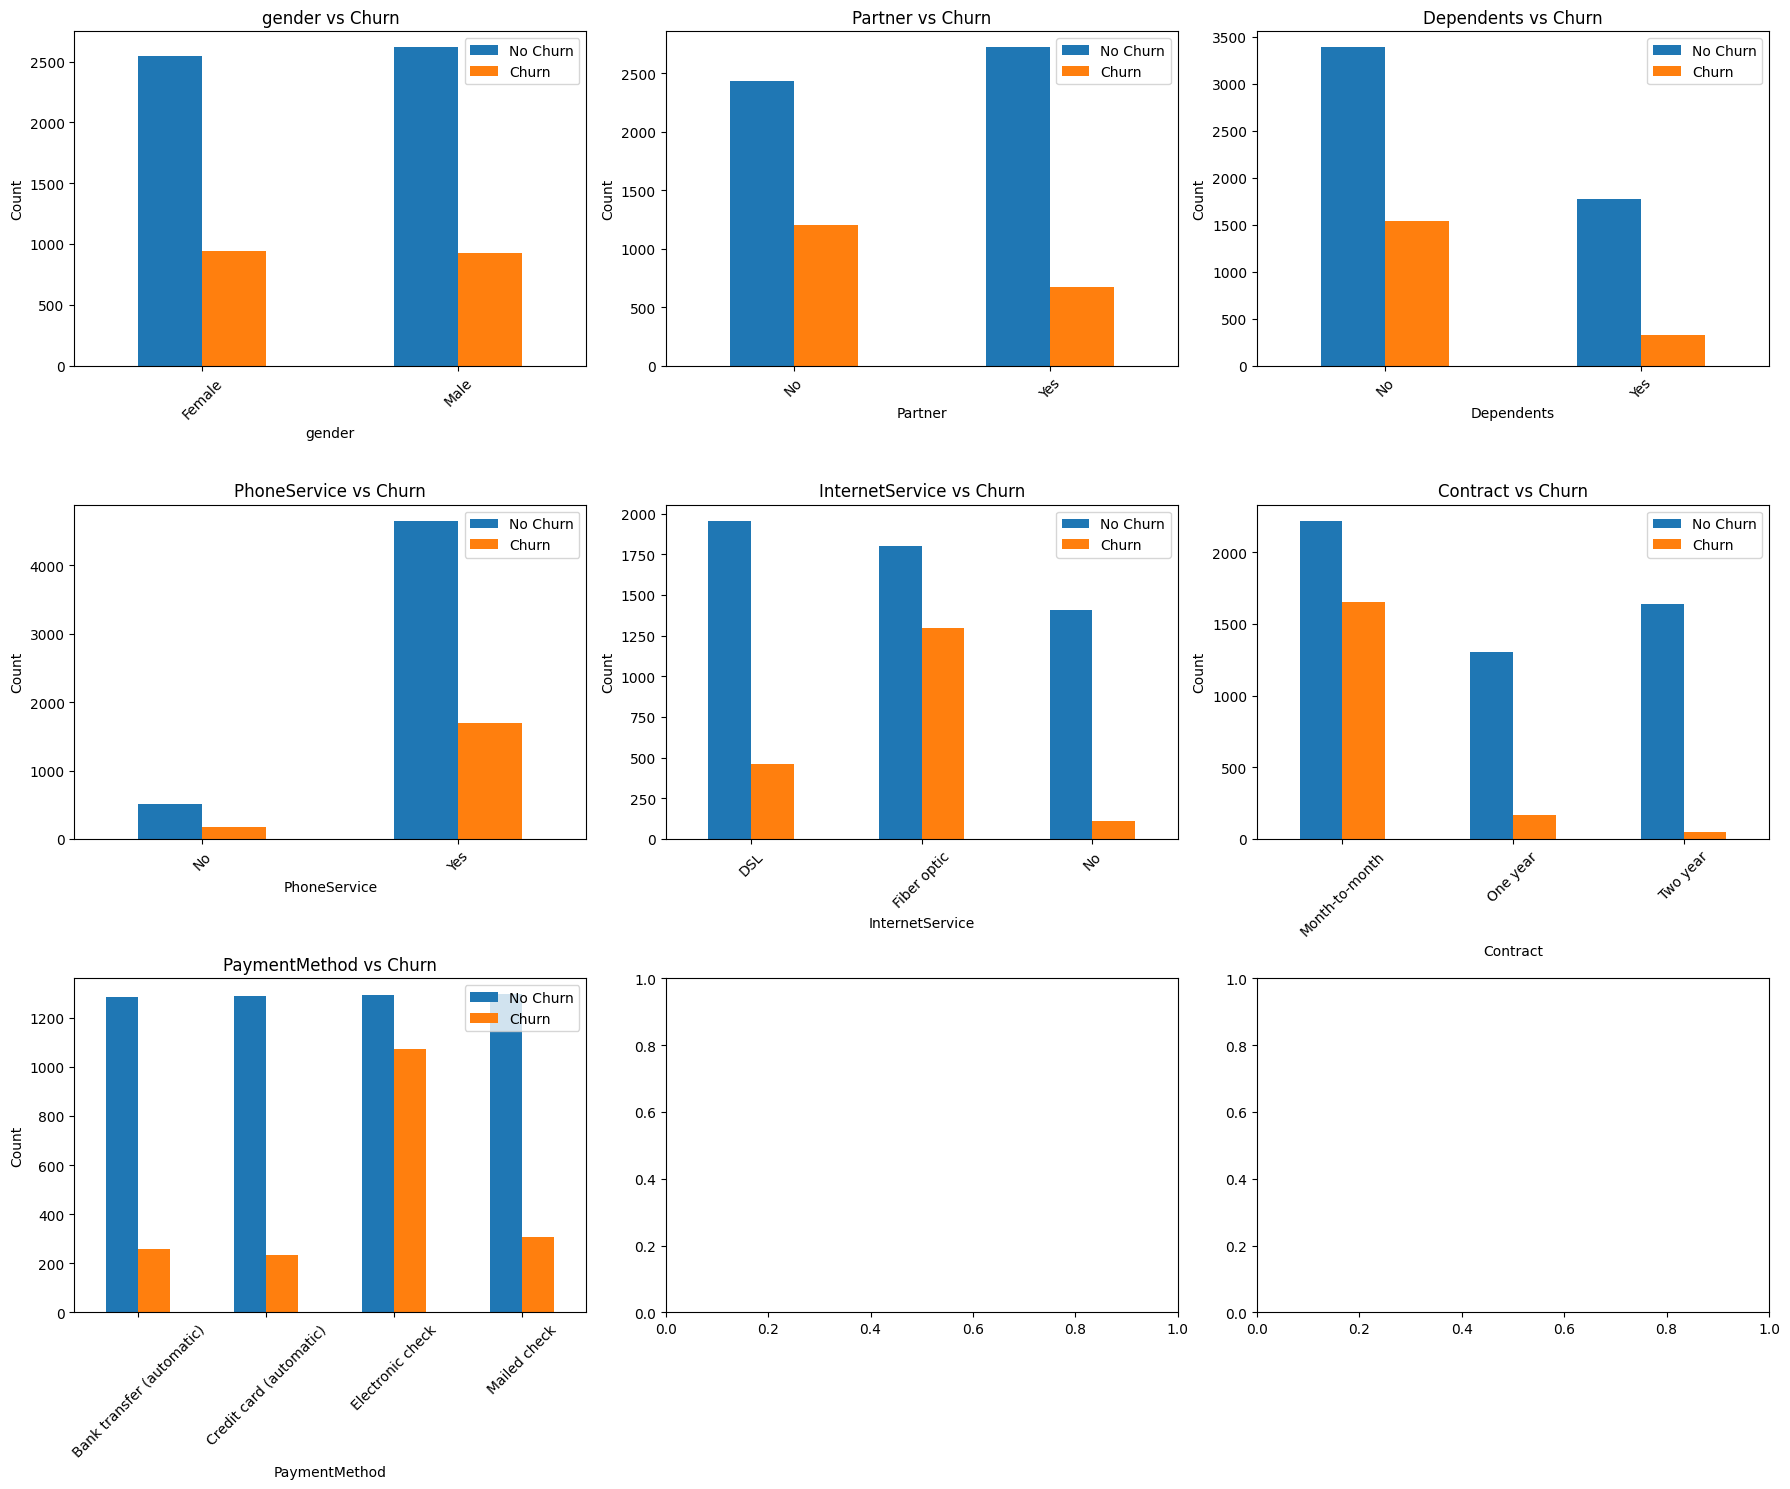

In [17]:
# Categorical features analysis
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService',
                    'Contract', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:9]):
    if col in df.columns:
        pd.crosstab(df[col], df['Churn']).plot(kind='bar', ax=axes[i], stacked=False)
        axes[i].set_title(f'{col} vs Churn')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].legend(['No Churn', 'Churn'])
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Split data


In [18]:
# Prepare features and target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')
print(f'\nTrain class distribution:')
print(y_train.value_counts(normalize=True))
print(f'\nTest class distribution:')
print(y_test.value_counts(normalize=True))


Train set size: 5625
Test set size: 1407

Train class distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Test class distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


## Feature Binarization (Scaling)


In [19]:
# Create binarized dataframe
X_binarized = pd.DataFrame(index=X.index)

# 1. SeniorCitizen (already binary)
X_binarized['SeniorCitizen'] = X['SeniorCitizen'] == 1

# 2. tenure (months)
tenure_thresholds = [0, 12, 24, 36, 48, 60, 72]
for threshold in tenure_thresholds:
    X_binarized[f'tenure_le_{threshold}'] = X['tenure'] <= threshold
    X_binarized[f'tenure_ge_{threshold}'] = X['tenure'] >= threshold

# 3. MonthlyCharges
monthly_thresholds = [20, 40, 60, 80, 100, 120]
for threshold in monthly_thresholds:
    X_binarized[f'monthly_le_{threshold}'] = X['MonthlyCharges'] <= threshold
    X_binarized[f'monthly_ge_{threshold}'] = X['MonthlyCharges'] >= threshold

# 4. TotalCharges
total_thresholds = [500, 1000, 2000, 3000, 4000, 5000]
for threshold in total_thresholds:
    X_binarized[f'total_le_{threshold}'] = X['TotalCharges'] <= threshold
    X_binarized[f'total_ge_{threshold}'] = X['TotalCharges'] >= threshold

# 5. gender
X_binarized['gender_Female'] = X['gender'] == 'Female'
X_binarized['gender_Male'] = X['gender'] == 'Male'

# 6. Partner
X_binarized['Partner_Yes'] = X['Partner'] == 'Yes'
X_binarized['Partner_No'] = X['Partner'] == 'No'

# 7. Dependents
X_binarized['Dependents_Yes'] = X['Dependents'] == 'Yes'
X_binarized['Dependents_No'] = X['Dependents'] == 'No'

# 8. PhoneService
X_binarized['PhoneService_Yes'] = X['PhoneService'] == 'Yes'
X_binarized['PhoneService_No'] = X['PhoneService'] == 'No'

# 9. MultipleLines
X_binarized['MultipleLines_Yes'] = X['MultipleLines'] == 'Yes'
X_binarized['MultipleLines_No'] = X['MultipleLines'] == 'No'
X_binarized['MultipleLines_NoPhone'] = X['MultipleLines'] == 'No phone service'

# 10. InternetService
X_binarized['InternetService_DSL'] = X['InternetService'] == 'DSL'
X_binarized['InternetService_Fiber'] = X['InternetService'] == 'Fiber optic'
X_binarized['InternetService_No'] = X['InternetService'] == 'No'

# 11. OnlineSecurity
X_binarized['OnlineSecurity_Yes'] = X['OnlineSecurity'] == 'Yes'
X_binarized['OnlineSecurity_No'] = X['OnlineSecurity'] == 'No'
X_binarized['OnlineSecurity_NoInternet'] = X['OnlineSecurity'] == 'No internet service'

# 12. OnlineBackup
X_binarized['OnlineBackup_Yes'] = X['OnlineBackup'] == 'Yes'
X_binarized['OnlineBackup_No'] = X['OnlineBackup'] == 'No'
X_binarized['OnlineBackup_NoInternet'] = X['OnlineBackup'] == 'No internet service'

# 13. DeviceProtection
X_binarized['DeviceProtection_Yes'] = X['DeviceProtection'] == 'Yes'
X_binarized['DeviceProtection_No'] = X['DeviceProtection'] == 'No'
X_binarized['DeviceProtection_NoInternet'] = X['DeviceProtection'] == 'No internet service'

# 14. TechSupport
X_binarized['TechSupport_Yes'] = X['TechSupport'] == 'Yes'
X_binarized['TechSupport_No'] = X['TechSupport'] == 'No'
X_binarized['TechSupport_NoInternet'] = X['TechSupport'] == 'No internet service'

# 15. StreamingTV
X_binarized['StreamingTV_Yes'] = X['StreamingTV'] == 'Yes'
X_binarized['StreamingTV_No'] = X['StreamingTV'] == 'No'
X_binarized['StreamingTV_NoInternet'] = X['StreamingTV'] == 'No internet service'

# 16. StreamingMovies
X_binarized['StreamingMovies_Yes'] = X['StreamingMovies'] == 'Yes'
X_binarized['StreamingMovies_No'] = X['StreamingMovies'] == 'No'
X_binarized['StreamingMovies_NoInternet'] = X['StreamingMovies'] == 'No internet service'

# 17. Contract
X_binarized['Contract_MonthToMonth'] = X['Contract'] == 'Month-to-month'
X_binarized['Contract_OneYear'] = X['Contract'] == 'One year'
X_binarized['Contract_TwoYear'] = X['Contract'] == 'Two year'

# 18. PaperlessBilling
X_binarized['PaperlessBilling_Yes'] = X['PaperlessBilling'] == 'Yes'
X_binarized['PaperlessBilling_No'] = X['PaperlessBilling'] == 'No'

# 19. PaymentMethod
X_binarized['PaymentMethod_Electronic'] = X['PaymentMethod'] == 'Electronic check'
X_binarized['PaymentMethod_Mailed'] = X['PaymentMethod'] == 'Mailed check'
X_binarized['PaymentMethod_BankTransfer'] = X['PaymentMethod'] == 'Bank transfer (automatic)'
X_binarized['PaymentMethod_CreditCard'] = X['PaymentMethod'] == 'Credit card (automatic)'

print(f'Original features: {X.shape[1]}')
print(f'Binarized features: {X_binarized.shape[1]}')
X_binarized.head()


Original features: 19
Binarized features: 80


,SeniorCitizen,tenure_le_0,tenure_ge_0,tenure_le_12,tenure_ge_12,tenure_le_24,tenure_ge_24,tenure_le_36,tenure_ge_36,tenure_le_48,tenure_ge_48,tenure_le_60,tenure_ge_60,tenure_le_72,tenure_ge_72,monthly_le_20,monthly_ge_20,monthly_le_40,monthly_ge_40,monthly_le_60,monthly_ge_60,monthly_le_80,monthly_ge_80,monthly_le_100,monthly_ge_100,monthly_le_120,monthly_ge_120,total_le_500,total_ge_500,total_le_1000,total_ge_1000,total_le_2000,total_ge_2000,total_le_3000,total_ge_3000,total_le_4000,total_ge_4000,total_le_5000,total_ge_5000,gender_Female,gender_Male,Partner_Yes,Partner_No,Dependents_Yes,Dependents_No,PhoneService_Yes,PhoneService_No,MultipleLines_Yes,MultipleLines_No,MultipleLines_NoPhone,InternetService_DSL,InternetService_Fiber,InternetService_No,OnlineSecurity_Yes,OnlineSecurity_No,OnlineSecurity_NoInternet,OnlineBackup_Yes,OnlineBackup_No,OnlineBackup_NoInternet,DeviceProtection_Yes,DeviceProtection_No,DeviceProtection_NoInternet,TechSupport_Yes,TechSupport_No,TechSupport_NoInternet,StreamingTV_Yes,StreamingTV_No,StreamingTV_NoInternet,StreamingMovies_Yes,StreamingMovies_No,StreamingMovies_NoInternet,Contract_MonthToMonth,Contract_OneYear,Contract_TwoYear,PaperlessBilling_Yes,PaperlessBilling_No,PaymentMethod_Electronic,PaymentMethod_Mailed,PaymentMethod_BankTransfer,PaymentMethod_CreditCard
0,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,False,True,True,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,True,False,True,False,False,False
1,False,False,True,False,True,False,True,True,False,True,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False,False,True,False,True,False,True,True,False,False,True,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False
2,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,True,True,False,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,True,False,False,True,False,False
3,False,False,True,False,True,False,True,False,True,True,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False,False,True,False,True,False,True,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False
4,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,True,False,True,False,False,False


In [20]:
# Split binarized data
X_train_bin = X_binarized.loc[X_train.index]
X_test_bin = X_binarized.loc[X_test.index]

print(f'Binarized train set: {X_train_bin.shape}')
print(f'Binarized test set: {X_test_bin.shape}')


Binarized train set: (5625, 80)
Binarized test set: (1407, 80)


## Lazy FCA Classification (Generators Method)


In [21]:
class LazyClassifierFCA:
    def __init__(self, min_cardinality=1, max_counter_examples=0, verbose=False):
        """
        Lazy FCA Classifier using Generators method.

        Parameters:
        - min_cardinality: minimum size of intersection to be considered
        - max_counter_examples: maximum number of counter-examples allowed
        - verbose: whether to print classification details
        """
        self.X_train = None
        self.y_train = None
        self.min_cardinality = min_cardinality
        self.max_counter_examples = max_counter_examples
        self.verbose = verbose

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        """Fit the classifier on training data."""
        self.X_train = X_train
        self.y_train = y_train

    def classify_sample(self, sample: pd.Series) -> int:
        """
        Classify a single sample using the Generators method.

        For each positive object, calculate intersection with test object.
        Check if intersection is a positive classifier (no counter-examples in negative class).
        Similar for negative objects.
        """
        # Split training data by class
        X_train_positive = self.X_train[self.y_train == 1]
        X_train_negative = self.X_train[self.y_train == 0]

        positive_classifiers = []
        negative_classifiers = []

        # Function to check if intersection is a positive classifier
        def is_positive_classifier(intersection):
            # Count how many positive and negative samples contain this intersection
            # A sample contains intersection if all True values in intersection are True in the sample
            mask = intersection == True
            if mask.sum() < self.min_cardinality:
                return False

            num_positive = ((X_train_positive.loc[:, mask] == True).all(axis=1)).sum()
            num_negative = ((X_train_negative.loc[:, mask] == True).all(axis=1)).sum()

            # Positive classifier: no counter-examples (no negatives) and at least one positive
            return num_negative <= self.max_counter_examples and num_positive > 0

        # Function to check if intersection is a negative classifier
        def is_negative_classifier(intersection):
            mask = intersection == True
            if mask.sum() < self.min_cardinality:
                return False

            num_positive = ((X_train_positive.loc[:, mask] == True).all(axis=1)).sum()
            num_negative = ((X_train_negative.loc[:, mask] == True).all(axis=1)).sum()

            # Negative classifier: no counter-examples (no positives) and at least one negative
            return num_positive <= self.max_counter_examples and num_negative > 0

        # Check intersections with positive objects
        for idx, pos_sample in X_train_positive.iterrows():
            intersection = sample & pos_sample
            if is_positive_classifier(intersection):
                positive_classifiers.append(intersection.sum())  # Store cardinality

        # Check intersections with negative objects
        for idx, neg_sample in X_train_negative.iterrows():
            intersection = sample & neg_sample
            if is_negative_classifier(intersection):
                negative_classifiers.append(intersection.sum())  # Store cardinality

        # Aggregate: use sum of cardinalities as weights
        pos_score = sum(positive_classifiers) if positive_classifiers else 0
        neg_score = sum(negative_classifiers) if negative_classifiers else 0

        if self.verbose:
            print(f"Sample {sample.name}: pos_score={pos_score}, neg_score={neg_score}, "
                  f"pos_count={len(positive_classifiers)}, neg_count={len(negative_classifiers)}")

        # Classify based on scores
        if pos_score > neg_score:
            return 1
        elif neg_score > pos_score:
            return 0
        else:
            # Default to majority class if equal
            return int(self.y_train.mode()[0])

    def predict(self, X_test: pd.DataFrame) -> List[int]:
        """Predict classes for test samples."""
        predictions = []
        import tqdm
        for idx, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test)):
            prediction = self.classify_sample(sample)
            predictions.append(prediction)
        return predictions


In [22]:
# Train and evaluate baseline FCA classifier
fca_classifier = LazyClassifierFCA(min_cardinality=1, max_counter_examples=0, verbose=False)
fca_classifier.fit(X_train_bin, y_train)

print("Predicting on test set...")
y_pred_fca = fca_classifier.predict(X_test_bin.iloc[:10])
print("Done!")


Predicting on test set...


100%|██████████| 10/10 [03:11<00:00, 19.15s/it]

Done!


## Quality Metrics


In [23]:
def calculate_metrics(y_true, y_pred):
    """Calculate all required quality metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'True Positive (TP)': tp,
        'True Negative (TN)': tn,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Negative Rate (Specificity)': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Negative Predictive Value (NPV)': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'False Positive Rate (FPR)': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'False Discovery Rate (FDR)': fp / (fp + tp) if (fp + tp) > 0 else 0,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (True Positive Rate)': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

# Calculate metrics for FCA
fca_metrics = calculate_metrics(y_test[:10].to_numpy().astype(int), y_pred_fca)

print("FCA Classifier Metrics:")
print("=" * 50)
for metric, value in fca_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


FCA Classifier Metrics:
True Positive (TP): 1
True Negative (TN): 7
False Positive (FP): 0
False Negative (FN): 2
True Negative Rate (Specificity): 1.0000
Negative Predictive Value (NPV): 0.7778
False Positive Rate (FPR): 0.0000
False Discovery Rate (FDR): 0.0000
Accuracy: 0.8000
Precision: 1.0000
Recall (True Positive Rate): 0.3333
F1 Score: 0.5000


In [24]:
y_pred_fca

[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]

## Comparison with Standard Algorithms


In [26]:
# Prepare non-binarized data for standard algorithms (need to encode categorical)
from sklearn.preprocessing import LabelEncoder

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded['TotalCharges'] = X_train_encoded['TotalCharges'].astype(float)
X_test_encoded['TotalCharges'] = X_test_encoded['TotalCharges'].astype(float)

# Encode categorical variables
label_encoders = {}
for col in X_train_encoded.select_dtypes(include=['object']).columns:
    print(col)
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
    X_test_encoded[col] = le.transform(X_test_encoded[col].astype(str))
    label_encoders[col] = le

print("Data prepared for standard algorithms")


gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
Data prepared for standard algorithms


In [27]:
X_train_encoded.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


In [28]:
y_test = y_test.to_numpy()

In [29]:
y_test = y_test.astype(int)

In [30]:
y_train = y_train.to_numpy().astype(int)

In [31]:
### K Nearest Neighbor (kNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_encoded, y_train)
y_pred_knn = knn_model.predict(X_test_encoded)
knn_metrics = calculate_metrics(y_test, y_pred_knn)

print("kNN Metrics:")
for metric, value in knn_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


kNN Metrics:
  True Positive (TP): 162
  True Negative (TN): 892
  False Positive (FP): 141
  False Negative (FN): 212
  True Negative Rate (Specificity): 0.8635
  Negative Predictive Value (NPV): 0.8080
  False Positive Rate (FPR): 0.1365
  False Discovery Rate (FDR): 0.4653
  Accuracy: 0.7491
  Precision: 0.5347
  Recall (True Positive Rate): 0.4332
  F1 Score: 0.4786


In [32]:
### Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_encoded, y_train)
y_pred_nb = nb_model.predict(X_test_encoded)
nb_metrics = calculate_metrics(y_test, y_pred_nb)

print("Naive Bayes Metrics:")
for metric, value in nb_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


Naive Bayes Metrics:
  True Positive (TP): 272
  True Negative (TN): 763
  False Positive (FP): 270
  False Negative (FN): 102
  True Negative Rate (Specificity): 0.7386
  Negative Predictive Value (NPV): 0.8821
  False Positive Rate (FPR): 0.2614
  False Discovery Rate (FDR): 0.4982
  Accuracy: 0.7356
  Precision: 0.5018
  Recall (True Positive Rate): 0.7273
  F1 Score: 0.5939


In [33]:
### Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_encoded, y_train)
y_pred_lr = lr_model.predict(X_test_encoded)
lr_metrics = calculate_metrics(y_test, y_pred_lr)

print("Logistic Regression Metrics:")
for metric, value in lr_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


Logistic Regression Metrics:
  True Positive (TP): 213
  True Negative (TN): 907
  False Positive (FP): 126
  False Negative (FN): 161
  True Negative Rate (Specificity): 0.8780
  Negative Predictive Value (NPV): 0.8493
  False Positive Rate (FPR): 0.1220
  False Discovery Rate (FDR): 0.3717
  Accuracy: 0.7960
  Precision: 0.6283
  Recall (True Positive Rate): 0.5695
  F1 Score: 0.5975


In [34]:
### SVM
svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_encoded, y_train)
y_pred_svm = svm_model.predict(X_test_encoded)
svm_metrics = calculate_metrics(y_test, y_pred_svm)

print("SVM Metrics:")
for metric, value in svm_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


SVM Metrics:
  True Positive (TP): 0
  True Negative (TN): 1033
  False Positive (FP): 0
  False Negative (FN): 374
  True Negative Rate (Specificity): 1.0000
  Negative Predictive Value (NPV): 0.7342
  False Positive Rate (FPR): 0.0000
  False Discovery Rate (FDR): 0
  Accuracy: 0.7342
  Precision: 0.0000
  Recall (True Positive Rate): 0.0000
  F1 Score: 0.0000


In [35]:
### Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_encoded, y_train)
y_pred_dt = dt_model.predict(X_test_encoded)
dt_metrics = calculate_metrics(y_test, y_pred_dt)

print("Decision Tree Metrics:")
for metric, value in dt_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


Decision Tree Metrics:
  True Positive (TP): 188
  True Negative (TN): 815
  False Positive (FP): 218
  False Negative (FN): 186
  True Negative Rate (Specificity): 0.7890
  Negative Predictive Value (NPV): 0.8142
  False Positive Rate (FPR): 0.2110
  False Discovery Rate (FDR): 0.5369
  Accuracy: 0.7129
  Precision: 0.4631
  Recall (True Positive Rate): 0.5027
  F1 Score: 0.4821


In [36]:
### Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_encoded, y_train)
y_pred_rf = rf_model.predict(X_test_encoded)
rf_metrics = calculate_metrics(y_test, y_pred_rf)

print("Random Forest Metrics:")
for metric, value in rf_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


Random Forest Metrics:
  True Positive (TP): 181
  True Negative (TN): 921
  False Positive (FP): 112
  False Negative (FN): 193
  True Negative Rate (Specificity): 0.8916
  Negative Predictive Value (NPV): 0.8268
  False Positive Rate (FPR): 0.1084
  False Discovery Rate (FDR): 0.3823
  Accuracy: 0.7832
  Precision: 0.6177
  Recall (True Positive Rate): 0.4840
  F1 Score: 0.5427


In [37]:
### XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_encoded, y_train)
y_pred_xgb = xgb_model.predict(X_test_encoded)
xgb_metrics = calculate_metrics(y_test, y_pred_xgb)

print("XGBoost Metrics:")
for metric, value in xgb_metrics.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


XGBoost Metrics:
  True Positive (TP): 189
  True Negative (TN): 887
  False Positive (FP): 146
  False Negative (FN): 185
  True Negative Rate (Specificity): 0.8587
  Negative Predictive Value (NPV): 0.8274
  False Positive Rate (FPR): 0.1413
  False Discovery Rate (FDR): 0.4358
  Accuracy: 0.7647
  Precision: 0.5642
  Recall (True Positive Rate): 0.5053
  F1 Score: 0.5331


### Comparison Summary


In [38]:
# Create comparison dataframe
comparison_data = {
    'FCA': fca_metrics,
    'kNN': knn_metrics,
    'Naive Bayes': nb_metrics,
    'Logistic Regression': lr_metrics,
    'SVM': svm_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}

comparison_df = pd.DataFrame(comparison_data).T
comparison_df


,True Positive (TP),True Negative (TN),False Positive (FP),False Negative (FN),True Negative Rate (Specificity),Negative Predictive Value (NPV),False Positive Rate (FPR),False Discovery Rate (FDR),Accuracy,Precision,Recall (True Positive Rate),F1 Score
FCA,1.0,7.0,0.0,2.0,1.000000,0.777778,0.000000,0.000000,0.800000,1.000000,0.333333,0.500000
kNN,162.0,892.0,141.0,212.0,0.863504,0.807971,0.136496,0.465347,0.749112,0.534653,0.433155,0.478582
Naive Bayes,272.0,763.0,270.0,102.0,0.738625,0.882081,0.261375,0.498155,0.735608,0.501845,0.727273,0.593886
Logistic Regression,213.0,907.0,126.0,161.0,0.878025,0.849251,0.121975,0.371681,0.796020,0.628319,0.569519,0.597475
SVM,0.0,1033.0,0.0,374.0,1.000000,0.734186,0.000000,0.000000,0.734186,0.000000,0.000000,0.000000
Decision Tree,188.0,815.0,218.0,186.0,0.788964,0.814186,0.211036,0.536946,0.712864,0.463054,0.502674,0.482051
Random Forest,181.0,921.0,112.0,193.0,0.891578,0.826750,0.108422,0.382253,0.783227,0.617747,0.483957,0.542729
XGBoost,189.0,887.0,146.0,185.0,0.858664,0.827425,0.141336,0.435821,0.764748,0.564179,0.505348,0.533145


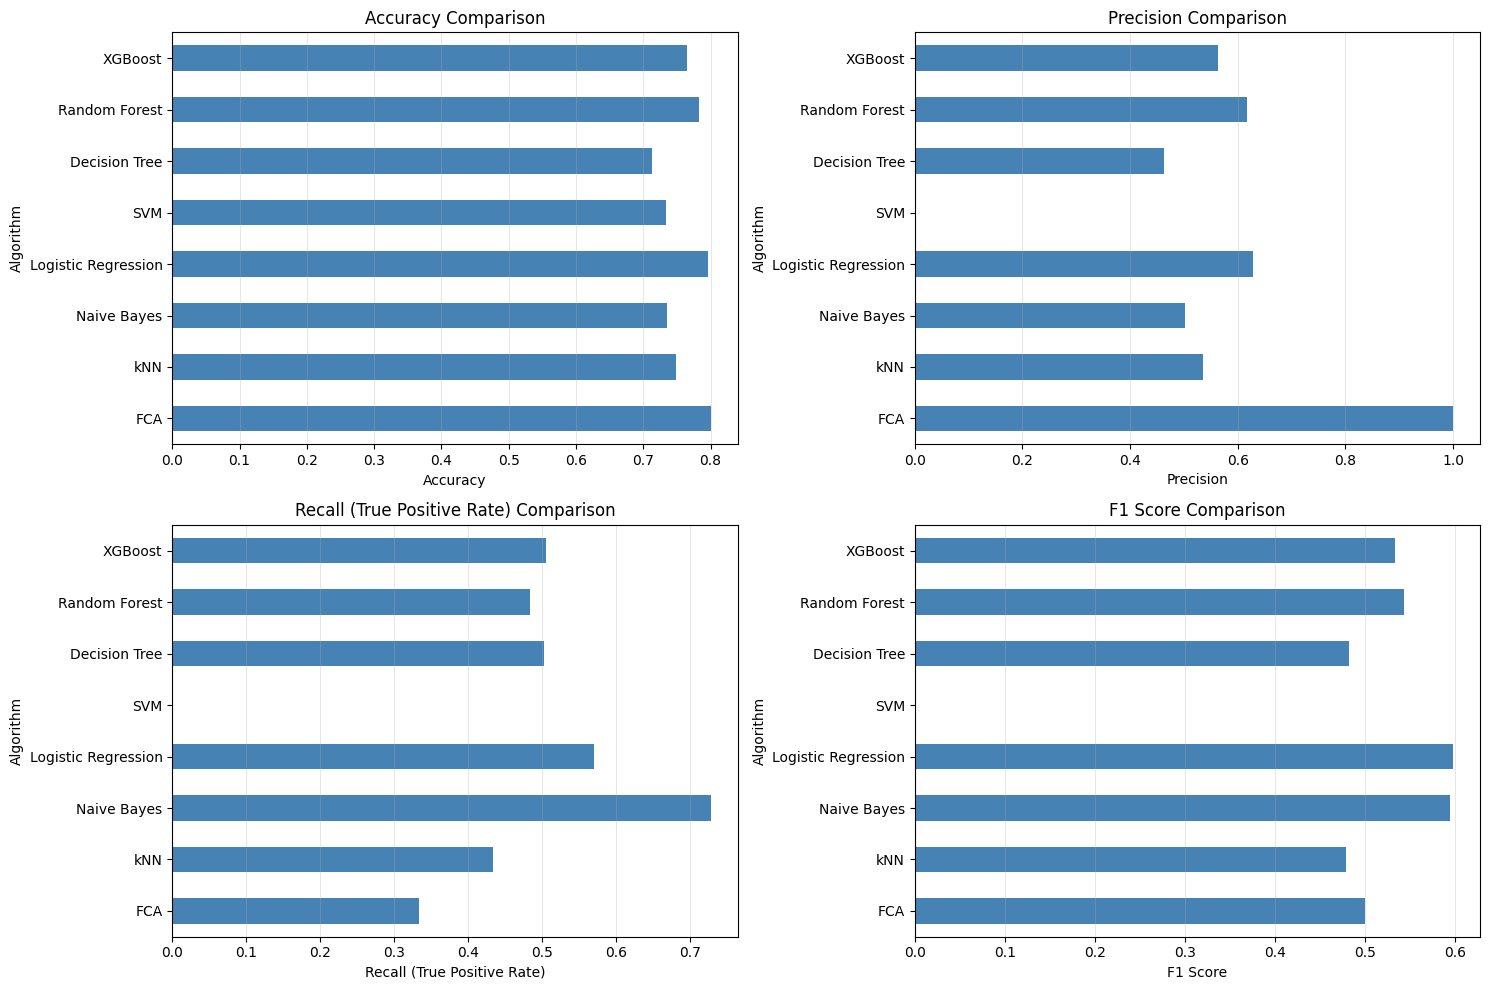

In [39]:
# Visualize key metrics comparison
key_metrics = ['Accuracy', 'Precision', 'Recall (True Positive Rate)', 'F1 Score']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(key_metrics):
    comparison_df[metric].plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('Algorithm')
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Improved FCA Algorithm


In [40]:
class ImprovedLazyClassifierFCA:
    def __init__(self, min_cardinality=2, max_counter_examples=1,
                 use_weighted_aggregation=True, use_confidence=True, verbose=False):
        """
        Improved Lazy FCA Classifier using Generators method.

        Improvements:
        1. Weighted aggregation based on classifier quality
        2. Confidence scoring based on classifier support
        3. Flexible counter-example tolerance
        4. Minimum cardinality threshold

        Parameters:
        - min_cardinality: minimum size of intersection to be considered
        - max_counter_examples: maximum number of counter-examples allowed
        - use_weighted_aggregation: use quality-weighted aggregation
        - use_confidence: use confidence scores
        - verbose: whether to print classification details
        """
        self.X_train = None
        self.y_train = None
        self.min_cardinality = min_cardinality
        self.max_counter_examples = max_counter_examples
        self.use_weighted_aggregation = use_weighted_aggregation
        self.use_confidence = use_confidence
        self.verbose = verbose

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        """Fit the classifier on training data."""
        self.X_train = X_train
        self.y_train = y_train

    def classify_sample(self, sample: pd.Series) -> int:
        """
        Classify a single sample using improved Generators method.
        """
        # Split training data by class
        X_train_positive = self.X_train[self.y_train == 1]
        X_train_negative = self.X_train[self.y_train == 0]

        positive_classifiers = []
        negative_classifiers = []

        # Function to check if intersection is a positive classifier and calculate quality
        def evaluate_positive_classifier(intersection):
            mask = intersection == True
            cardinality = mask.sum()

            if cardinality < self.min_cardinality:
                return None

            # Count support
            pos_support = ((X_train_positive.loc[:, mask] == True).all(axis=1)).sum()
            neg_support = ((X_train_negative.loc[:, mask] == True).all(axis=1)).sum()

            # Check if it's a valid classifier
            if neg_support <= self.max_counter_examples and pos_support > 0:
                # Calculate quality: support ratio and cardinality
                total_support = pos_support + neg_support
                purity = pos_support / total_support if total_support > 0 else 0
                quality = purity * (1 + np.log1p(cardinality)) * (1 + np.log1p(pos_support))
                return {
                    'cardinality': cardinality,
                    'pos_support': pos_support,
                    'neg_support': neg_support,
                    'quality': quality,
                    'purity': purity
                }
            return None

        # Function to check if intersection is a negative classifier and calculate quality
        def evaluate_negative_classifier(intersection):
            mask = intersection == True
            cardinality = mask.sum()

            if cardinality < self.min_cardinality:
                return None

            # Count support
            pos_support = ((X_train_positive.loc[:, mask] == True).all(axis=1)).sum()
            neg_support = ((X_train_negative.loc[:, mask] == True).all(axis=1)).sum()

            # Check if it's a valid classifier
            if pos_support <= self.max_counter_examples and neg_support > 0:
                # Calculate quality: support ratio and cardinality
                total_support = pos_support + neg_support
                purity = neg_support / total_support if total_support > 0 else 0
                quality = purity * (1 + np.log1p(cardinality)) * (1 + np.log1p(neg_support))
                return {
                    'cardinality': cardinality,
                    'pos_support': pos_support,
                    'neg_support': neg_support,
                    'quality': quality,
                    'purity': purity
                }
            return None

        # Check intersections with positive objects
        for idx, pos_sample in X_train_positive.iterrows():
            intersection = sample & pos_sample
            result = evaluate_positive_classifier(intersection)
            if result is not None:
                positive_classifiers.append(result)

        # Check intersections with negative objects
        for idx, neg_sample in X_train_negative.iterrows():
            intersection = sample & neg_sample
            result = evaluate_negative_classifier(intersection)
            if result is not None:
                negative_classifiers.append(result)

        # Improved aggregation
        if self.use_weighted_aggregation:
            # Weight by quality
            pos_score = sum(c['quality'] for c in positive_classifiers) if positive_classifiers else 0
            neg_score = sum(c['quality'] for c in negative_classifiers) if negative_classifiers else 0
        else:
            # Simple sum of cardinalities
            pos_score = sum(c['cardinality'] for c in positive_classifiers) if positive_classifiers else 0
            neg_score = sum(c['cardinality'] for c in negative_classifiers) if negative_classifiers else 0

        # Confidence calculation
        if self.use_confidence:
            total_classifiers = len(positive_classifiers) + len(negative_classifiers)
            if total_classifiers > 0:
                pos_confidence = len(positive_classifiers) / total_classifiers
                neg_confidence = len(negative_classifiers) / total_classifiers
                # Adjust scores by confidence
                pos_score *= (1 + pos_confidence)
                neg_score *= (1 + neg_confidence)

        if self.verbose:
            print(f"Sample {sample.name}: pos_score={pos_score:.2f}, neg_score={neg_score:.2f}, "
                  f"pos_count={len(positive_classifiers)}, neg_count={len(negative_classifiers)}")

        # Classify based on scores
        if pos_score > neg_score:
            return 1
        elif neg_score > pos_score:
            return 0
        else:
            # Default to majority class if equal
            import scipy.stats
            return int(scipy.stats.mode(self.y_train)[0])

    def predict(self, X_test: pd.DataFrame) -> List[int]:
        """Predict classes for test samples."""
        predictions = []
        import tqdm
        for idx, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test)):
            prediction = self.classify_sample(sample)
            predictions.append(prediction)
        return predictions


In [41]:
# Train and evaluate improved FCA classifier
improved_fca_classifier = ImprovedLazyClassifierFCA(
    min_cardinality=2,
    max_counter_examples=1,
    use_weighted_aggregation=True,
    use_confidence=True,
    verbose=False
)
improved_fca_classifier.fit(X_train_bin, y_train)

print("Predicting on test set with improved FCA...")
y_pred_fca_improved = improved_fca_classifier.predict(X_test_bin.iloc[:10])
print("Done!")


Predicting on test set with improved FCA...


100%|██████████| 10/10 [03:29<00:00, 20.99s/it]

Done!


In [43]:
# Calculate metrics for improved FCA
fca_improved_metrics = calculate_metrics(y_test[:10], y_pred_fca_improved)

print("Improved FCA Classifier Metrics:")
print("=" * 50)
for metric, value in fca_improved_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


Improved FCA Classifier Metrics:
True Positive (TP): 1
True Negative (TN): 7
False Positive (FP): 0
False Negative (FN): 2
True Negative Rate (Specificity): 1.0000
Negative Predictive Value (NPV): 0.7778
False Positive Rate (FPR): 0.0000
False Discovery Rate (FDR): 0.0000
Accuracy: 0.8000
Precision: 1.0000
Recall (True Positive Rate): 0.3333
F1 Score: 0.5000


In [44]:
# Compare baseline and improved FCA
fca_comparison = pd.DataFrame({
    'Baseline FCA': fca_metrics,
    'Improved FCA': fca_improved_metrics
}).T
print("FCA Baseline vs Improved:")
print(fca_comparison[['Accuracy', 'Precision', 'Recall (True Positive Rate)', 'F1 Score']])


FCA Baseline vs Improved:
              Accuracy  Precision  Recall (True Positive Rate)  F1 Score
Baseline FCA       0.8        1.0                     0.333333       0.5
Improved FCA       0.8        1.0                     0.333333       0.5


## Interpretability Analysis


In [46]:
### FCA Interpretability: Example Classifiers

# Analyze classifiers for a sample test case
sample_idx = X_test_bin.index[0]
sample = X_test_bin.loc[sample_idx]

# Get positive and negative training sets
X_train_positive = X_train_bin[y_train == 1]
X_train_negative = X_train_bin[y_train == 0]

print(f"Analyzing sample {sample_idx} (True class: {y_test[sample_idx]})")
print(f"Predicted class: {y_pred_fca_improved[0]}")
print("\n" + "="*60)

# Find positive classifiers
positive_classifiers_info = []
for idx, pos_sample in X_train_positive.iterrows():
    intersection = sample & pos_sample
    mask = intersection == True
    cardinality = mask.sum()

    if cardinality >= 2:  # min_cardinality
        pos_support = ((X_train_positive.loc[:, mask] == True).all(axis=1)).sum()
        neg_support = ((X_train_negative.loc[:, mask] == True).all(axis=1)).sum()

        if neg_support <= 1 and pos_support > 0:  # max_counter_examples = 1
            features = X_train_bin.columns[mask].tolist()
            positive_classifiers_info.append({
                'features': features,
                'cardinality': cardinality,
                'pos_support': pos_support,
                'neg_support': neg_support,
                'purity': pos_support / (pos_support + neg_support) if (pos_support + neg_support) > 0 else 0
            })

# Find negative classifiers
negative_classifiers_info = []
for idx, neg_sample in X_train_negative.iterrows():
    intersection = sample & neg_sample
    mask = intersection == True
    cardinality = mask.sum()

    if cardinality >= 2:  # min_cardinality
        pos_support = ((X_train_positive.loc[:, mask] == True).all(axis=1)).sum()
        neg_support = ((X_train_negative.loc[:, mask] == True).all(axis=1)).sum()

        if pos_support <= 1 and neg_support > 0:  # max_counter_examples = 1
            features = X_train_bin.columns[mask].tolist()
            negative_classifiers_info.append({
                'features': features,
                'cardinality': cardinality,
                'pos_support': pos_support,
                'neg_support': neg_support,
                'purity': neg_support / (pos_support + neg_support) if (pos_support + neg_support) > 0 else 0
            })

# Sort by quality (purity * cardinality)
positive_classifiers_info.sort(key=lambda x: x['purity'] * x['cardinality'], reverse=True)
negative_classifiers_info.sort(key=lambda x: x['purity'] * x['cardinality'], reverse=True)

print(f"\nTop 5 Positive Classifiers (supporting class 1):")
print("-" * 60)
for i, clf in enumerate(positive_classifiers_info[:5], 1):
    print(f"\n{i}. Cardinality: {clf['cardinality']}, Purity: {clf['purity']:.3f}")
    print(f"   Support: {clf['pos_support']} positive, {clf['neg_support']} negative")
    print(f"   Features: {', '.join(clf['features'][:5])}...")  # Show first 5 features

print(f"\n\nTop 5 Negative Classifiers (supporting class 0):")
print("-" * 60)
for i, clf in enumerate(negative_classifiers_info[:5], 1):
    print(f"\n{i}. Cardinality: {clf['cardinality']}, Purity: {clf['purity']:.3f}")
    print(f"   Support: {clf['neg_support']} negative, {clf['pos_support']} positive")
    print(f"   Features: {', '.join(clf['features'][:5])}...")  # Show first 5 features


Analyzing sample 974 (True class: 1)
Predicted class: 0


Top 5 Positive Classifiers (supporting class 1):
------------------------------------------------------------

1. Cardinality: 28, Purity: 1.000
   Support: 1 positive, 0 negative
   Features: tenure_ge_0, tenure_ge_12, tenure_ge_24, tenure_ge_36, tenure_le_60...

2. Cardinality: 27, Purity: 1.000
   Support: 1 positive, 0 negative
   Features: tenure_ge_0, tenure_ge_12, tenure_ge_24, tenure_ge_36, tenure_ge_48...

3. Cardinality: 27, Purity: 1.000
   Support: 1 positive, 0 negative
   Features: tenure_ge_0, tenure_ge_12, tenure_ge_24, tenure_ge_36, tenure_le_60...

4. Cardinality: 27, Purity: 1.000
   Support: 1 positive, 0 negative
   Features: tenure_ge_0, tenure_ge_12, tenure_ge_24, tenure_ge_36, tenure_ge_48...

5. Cardinality: 26, Purity: 1.000
   Support: 1 positive, 0 negative
   Features: tenure_ge_0, tenure_ge_12, tenure_ge_24, tenure_ge_36, tenure_le_60...


Top 5 Negative Classifiers (supporting class 0):
-----------

In [47]:
### Feature Importance Analysis

# For Decision Tree and Random Forest (interpretable models)
print("Decision Tree Feature Importance (Top 10):")
print("-" * 60)
dt_feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
print(dt_feature_importance.head(10))

print("\n\nRandom Forest Feature Importance (Top 10):")
print("-" * 60)
rf_feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(rf_feature_importance.head(10))


Decision Tree Feature Importance (Top 10):
------------------------------------------------------------
             feature  importance
17    MonthlyCharges    0.210361
18      TotalCharges    0.209673
14          Contract    0.173999
4             tenure    0.110475
8     OnlineSecurity    0.047512
16     PaymentMethod    0.043534
7    InternetService    0.030318
0             gender    0.026637
15  PaperlessBilling    0.019409
6      MultipleLines    0.017324


Random Forest Feature Importance (Top 10):
------------------------------------------------------------
            feature  importance
18     TotalCharges    0.184908
17   MonthlyCharges    0.177222
4            tenure    0.159101
14         Contract    0.083028
16    PaymentMethod    0.050095
8    OnlineSecurity    0.048429
11      TechSupport    0.041551
0            gender    0.028497
7   InternetService    0.028416
9      OnlineBackup    0.028212


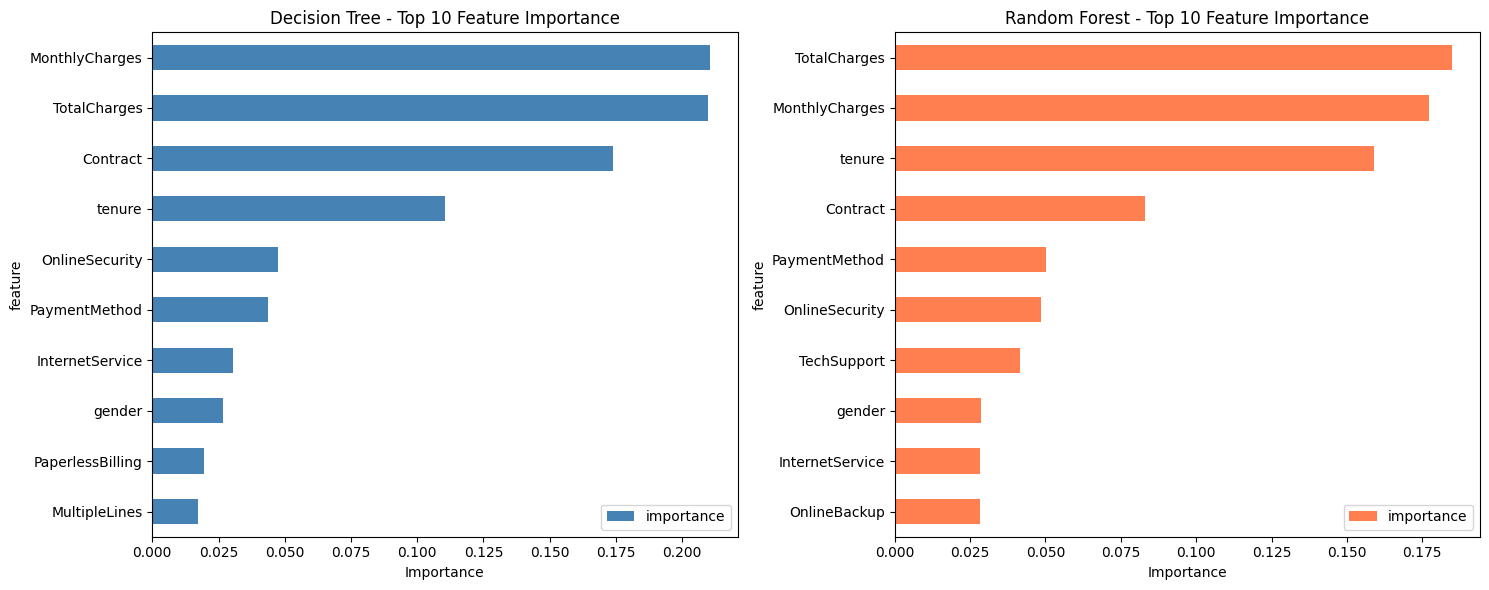

In [48]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

dt_feature_importance.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Decision Tree - Top 10 Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

rf_feature_importance.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Random Forest - Top 10 Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Logistic Regression Coefficients (Top 15 by absolute value):
------------------------------------------------------------
             feature  coefficient
5       PhoneService    -1.001052
14          Contract    -0.752705
15  PaperlessBilling     0.309607
8     OnlineSecurity    -0.291328
11       TechSupport    -0.272655
3         Dependents    -0.249117
7    InternetService     0.223817
1      SeniorCitizen     0.210339
9       OnlineBackup    -0.159699
6      MultipleLines     0.100339
16     PaymentMethod     0.080127
10  DeviceProtection    -0.062037
4             tenure    -0.056423
0             gender    -0.030641
17    MonthlyCharges     0.022630


<Figure size 1000x800 with 0 Axes>

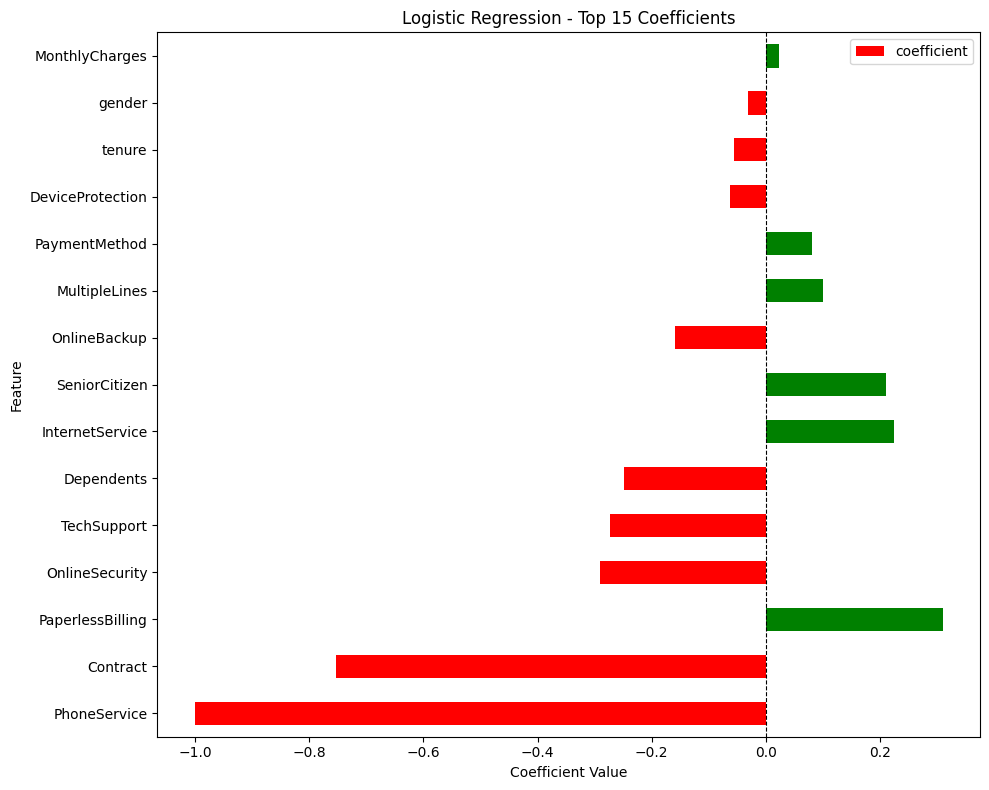

In [49]:
### Logistic Regression Coefficients (Interpretability)

# Get coefficients for logistic regression
lr_coefficients = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Logistic Regression Coefficients (Top 15 by absolute value):")
print("-" * 60)
print(lr_coefficients.head(15))

# Visualize coefficients
plt.figure(figsize=(10, 8))
top_coefs = lr_coefficients.head(15)
colors = ['red' if x < 0 else 'green' for x in top_coefs['coefficient']]
top_coefs.plot(x='feature', y='coefficient', kind='barh', color=colors, figsize=(10, 8))
plt.title('Logistic Regression - Top 15 Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


### Interpretability Comparison Summary

**FCA (Improved):**
- **Strengths**:
  - Highly interpretable: provides explicit feature combinations (classifiers) that explain predictions
  - Each classifier shows which features together indicate a class
  - Can show support (how many examples match) and purity (class distribution)
  - Human-readable rules in the form of feature intersections
  
- **Weaknesses**:
  - Can produce many classifiers, making it harder to summarize
  - Classifiers are specific to each test sample (lazy learning)

**Decision Tree:**
- **Strengths**:
  - Very interpretable: provides if-then rules
  - Can visualize the entire decision path
  - Feature importance shows which features matter most
  
- **Weaknesses**:
  - Can be complex for deep trees
  - Single tree may not capture all patterns

**Random Forest:**
- **Strengths**:
  - Feature importance shows overall feature relevance
  - More stable than single decision tree
  
- **Weaknesses**:
  - Less interpretable than single tree (ensemble of many trees)
  - Hard to trace exact decision path

**Logistic Regression:**
- **Strengths**:
  - Coefficients directly show feature impact
  - Easy to understand: positive coefficient increases probability of class 1
  
- **Weaknesses**:
  - Assumes linear relationships
  - Coefficients may not capture interactions

**kNN, Naive Bayes, SVM, XGBoost:**
- **Weaknesses**:
  - Generally less interpretable
  - kNN: relies on similarity to neighbors (hard to explain why)
  - Naive Bayes: assumes feature independence (unrealistic)
  - SVM: complex decision boundaries
  - XGBoost: ensemble of trees (complex)

**Conclusion**: FCA provides unique interpretability by showing explicit feature combinations that characterize each class, making it valuable for understanding why specific predictions are made.


## Final Results Summary


In [50]:
# Final comparison including improved FCA
final_comparison_data = {
    'FCA (Baseline)': fca_metrics,
    'FCA (Improved)': fca_improved_metrics,
    'kNN': knn_metrics,
    'Naive Bayes': nb_metrics,
    'Logistic Regression': lr_metrics,
    'SVM': svm_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}

final_comparison_df = pd.DataFrame(final_comparison_data).T

# Display key metrics
key_metrics_display = ['Accuracy', 'Precision', 'Recall (True Positive Rate)', 'F1 Score',
                       'True Negative Rate (Specificity)', 'False Positive Rate (FPR)']
print("Final Comparison - Key Metrics:")
print("=" * 80)
print(final_comparison_df[key_metrics_display].round(4))


Final Comparison - Key Metrics:
                     Accuracy  Precision  Recall (True Positive Rate)  \
FCA (Baseline)         0.8000     1.0000                       0.3333   
FCA (Improved)         0.8000     1.0000                       0.3333   
kNN                    0.7491     0.5347                       0.4332   
Naive Bayes            0.7356     0.5018                       0.7273   
Logistic Regression    0.7960     0.6283                       0.5695   
SVM                    0.7342     0.0000                       0.0000   
Decision Tree          0.7129     0.4631                       0.5027   
Random Forest          0.7832     0.6177                       0.4840   
XGBoost                0.7647     0.5642                       0.5053   

                     F1 Score  True Negative Rate (Specificity)  \
FCA (Baseline)         0.5000                            1.0000   
FCA (Improved)         0.5000                            1.0000   
kNN                    0.4786       

In [51]:
# Rank algorithms by F1 Score (balanced metric)
print("\n\nAlgorithm Ranking by F1 Score:")
print("=" * 80)
ranking = final_comparison_df['F1 Score'].sort_values(ascending=False)
for i, (algo, score) in enumerate(ranking.items(), 1):
    print(f"{i}. {algo}: {score:.4f}")




Algorithm Ranking by F1 Score:
1. Logistic Regression: 0.5975
2. Naive Bayes: 0.5939
3. Random Forest: 0.5427
4. XGBoost: 0.5331
5. FCA (Baseline): 0.5000
6. FCA (Improved): 0.5000
7. Decision Tree: 0.4821
8. kNN: 0.4786
9. SVM: 0.0000


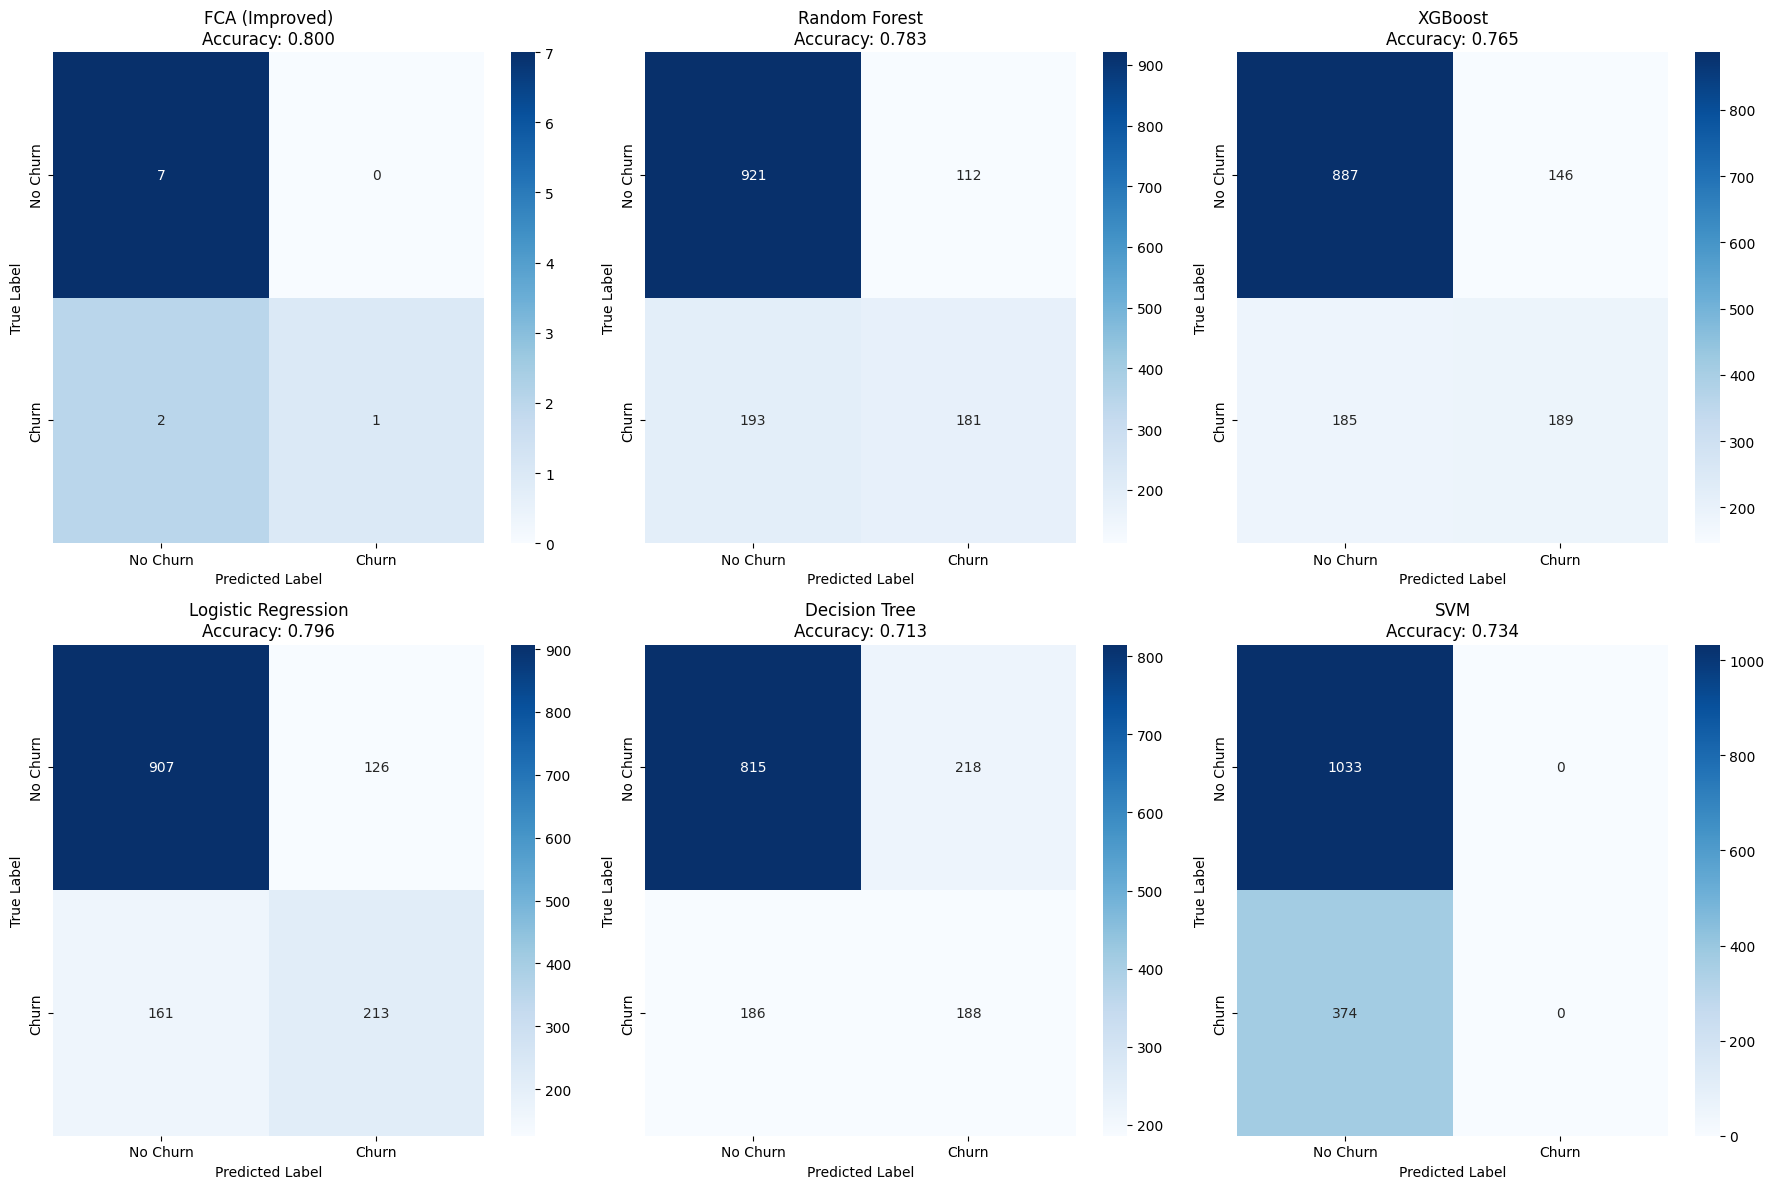

In [55]:
# Confusion matrices comparison for key algorithms
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

algorithms = [
    ('FCA (Improved)', y_pred_fca_improved),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('SVM', y_pred_svm)
]

for i, (name, y_pred) in enumerate(algorithms):
    cm = confusion_matrix(y_test[:len(y_pred)], y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test[:len(y_pred)], y_pred):.3f}')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
